In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import timedelta
import math
from scipy import stats
pd.set_option('display.max_columns',None)

In [34]:
def plot_distribution(data, col):
    
   
    
    fig, ax = plt.subplots(1, 1, figsize=(6,4))

    
   
        
    sns.histplot(data[col], bins=30, kde=True,  color='steelblue')
        
        # Add mean and median lines
    mean_val = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
        
        # Title with null info
    null_pct = data[col].isnull().mean() * 100
    ax.set_title(f'{col}\n(Nulls: {null_pct:.1f}%)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('')
    
    
    # plt.suptitle('Distribution of ', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()



In [2]:
def get_dataset(dataset:str)->str:
    try:
        return pd.read_csv(os.path.join('..','..','data','processed',f'{dataset}.csv'))
    except Exception as e:
        warnings.warn(f'"{dataset}" dataset not present.')
        return None

In [16]:
data = get_dataset('cleaned_trained_data')

In [17]:
# Convert columns to their appropriate datatypes.

date_col = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
            'order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date']

number_col = ['payment_sequential','payment_installments','order_item_id','seller_zip_code_prefix']

for col in date_col:
    data[col] = pd.to_datetime( data[col])
    

for col in number_col:
    data[col] = data[col].astype('Int64')



In [18]:
data['product_volume_cm3'] = data['product_length_cm'] * data['product_height_cm'] * data['product_width_cm']

data.drop(columns=['product_length_cm','product_height_cm','product_width_cm'],inplace=True)

In [19]:
# add target date column.
data['delivery_days'] = (data['order_delivered_customer_date'] - data['order_purchase_timestamp']).dt.days

In [21]:
# after analyzing we decided to this
unsullfull_col =['payment_sequential','customer_zip_code_prefix','customer_latitude','customer_longitude',
                 # 'order_item_id',
                 'product_photos_qty','seller_zip_code_prefix','seller_latitude','seller_longitude']

data.drop(columns=unsullfull_col,inplace=True)

In [22]:
data['ordered_day_week'] =  data['order_purchase_timestamp'].dt.day_of_week

data['is_weekend'] =  np.where(data['ordered_day_week'] >=5,1,0)

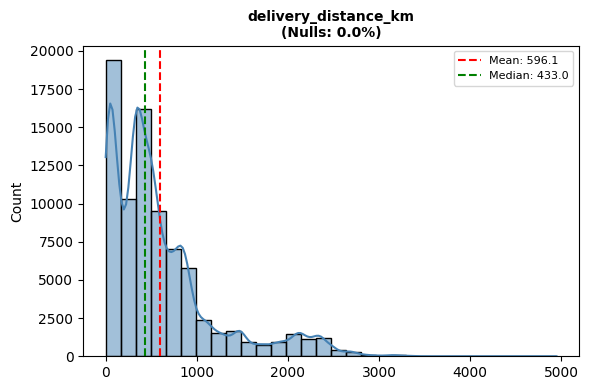

In [35]:
plot_distribution(data,'delivery_distance_km')

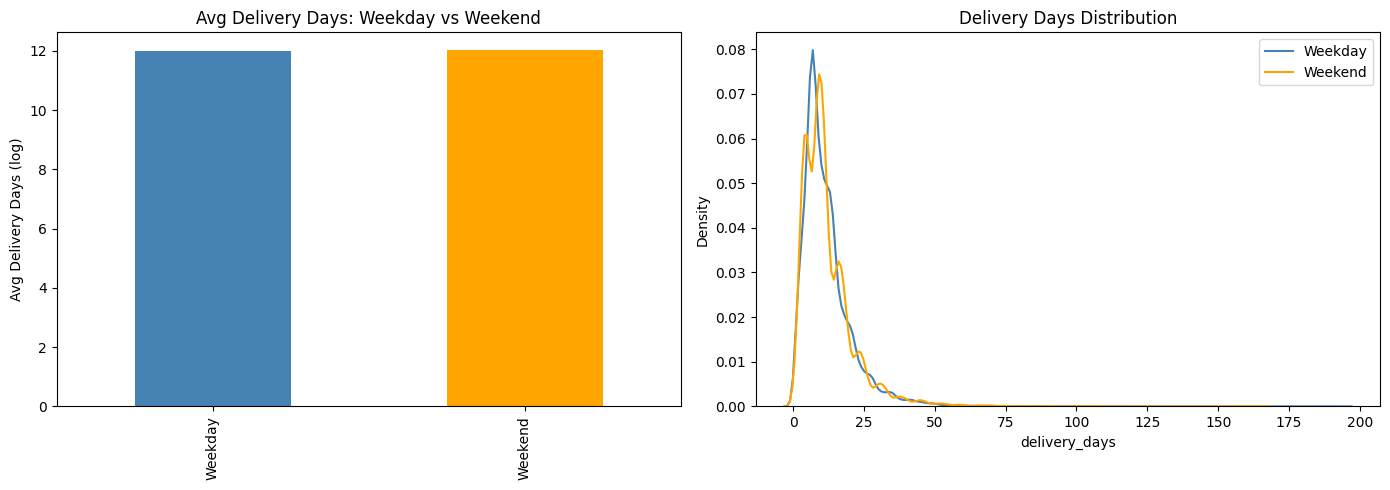

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average delivery days by weekend/weekday
avg_delivery = data.groupby('is_weekend')['delivery_days'].mean()
avg_delivery.index = ['Weekday', 'Weekend']
avg_delivery.plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Avg Delivery Days: Weekday vs Weekend')
axes[0].set_ylabel('Avg Delivery Days (log)')



# Plot 2: Distribution comparison
sns.kdeplot(data[data['is_weekend']==0]['delivery_days'], 
            ax=axes[1], label='Weekday', color='steelblue')
sns.kdeplot(data[data['is_weekend']==1]['delivery_days'], 
            ax=axes[1], label='Weekend', color='orange')
axes[1].set_title('Delivery Days Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:

weekday = data[data['is_weekend']==0]['delivery_days']
weekend = data[data['is_weekend']==1]['delivery_days']

t_stat, p_value = stats.ttest_ind(weekday, weekend)

print(f"Weekday mean: {weekday.mean():.3f}")
print(f"Weekend mean: {weekend.mean():.3f}")
print(f"T-statistic:  {t_stat:.3f}")
print(f"P-value:      {p_value:.5f}")

Weekday mean: 11.982
Weekend mean: 12.020
T-statistic:  -0.481
P-value:      0.63060


In [43]:
print(data.groupby('is_weekend')['delivery_days'].agg(['mean','median','count']))


                 mean  median  count
is_weekend                          
0           11.982053    10.0  62741
1           12.019938    10.0  18307


In [44]:
# Check day mapping
print(data['ordered_day_week'].value_counts().sort_index())
# 0=Monday, 1=Tuesday, ... 5=Saturday, 6=Sunday

# Check weekend flag
print(data.groupby('ordered_day_week')['is_weekend'].first())
# 5 and 6 should be 1, rest should be 0

# Check balance
print(data['is_weekend'].value_counts())
# Weekend should be roughly 2/7 ≈ 28% of data

ordered_day_week
0    13321
1    13140
2    12652
3    12115
4    11513
5     8713
6     9594
Name: count, dtype: int64
ordered_day_week
0    0
1    0
2    0
3    0
4    0
5    1
6    1
Name: is_weekend, dtype: int64
is_weekend
0    62741
1    18307
Name: count, dtype: int64


In [45]:
data.drop(columns=['is_weekend', 'ordered_day_week'], inplace=True)

### Categorical Column 

In [47]:
data.describe(include='str')

,order_id,customer_id,order_status,payment_type,customer_unique_id,customer_city,customer_state,product_id,seller_id,product_category_name,product_category_name_english,seller_city,seller_state
count,81048,81048,81048,81048,81048,81048,81048,81048,81048,81048,81048,81048,81048
unique,72805,72805,1,4,70914,3719,27,26707,2769,71,71,573,22
top,1b15974a0141d54e36626dca3fdc731a,be1b70680b9f9694d8c70f41fa3dc92b,delivered,credit_card,c8460e4251689ba205045f3ea17884a1,sao paulo,SP,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,cama_mesa_banho,bed_bath_table,sao paulo,SP
freq,17,17,81048,61226,19,12872,34349,385,1459,8197,8197,20192,57747


In [48]:
data.drop(columns = ['order_status','product_category_name'],inplace=True)

In [52]:
cat_cols = data.select_dtypes(include='str').columns


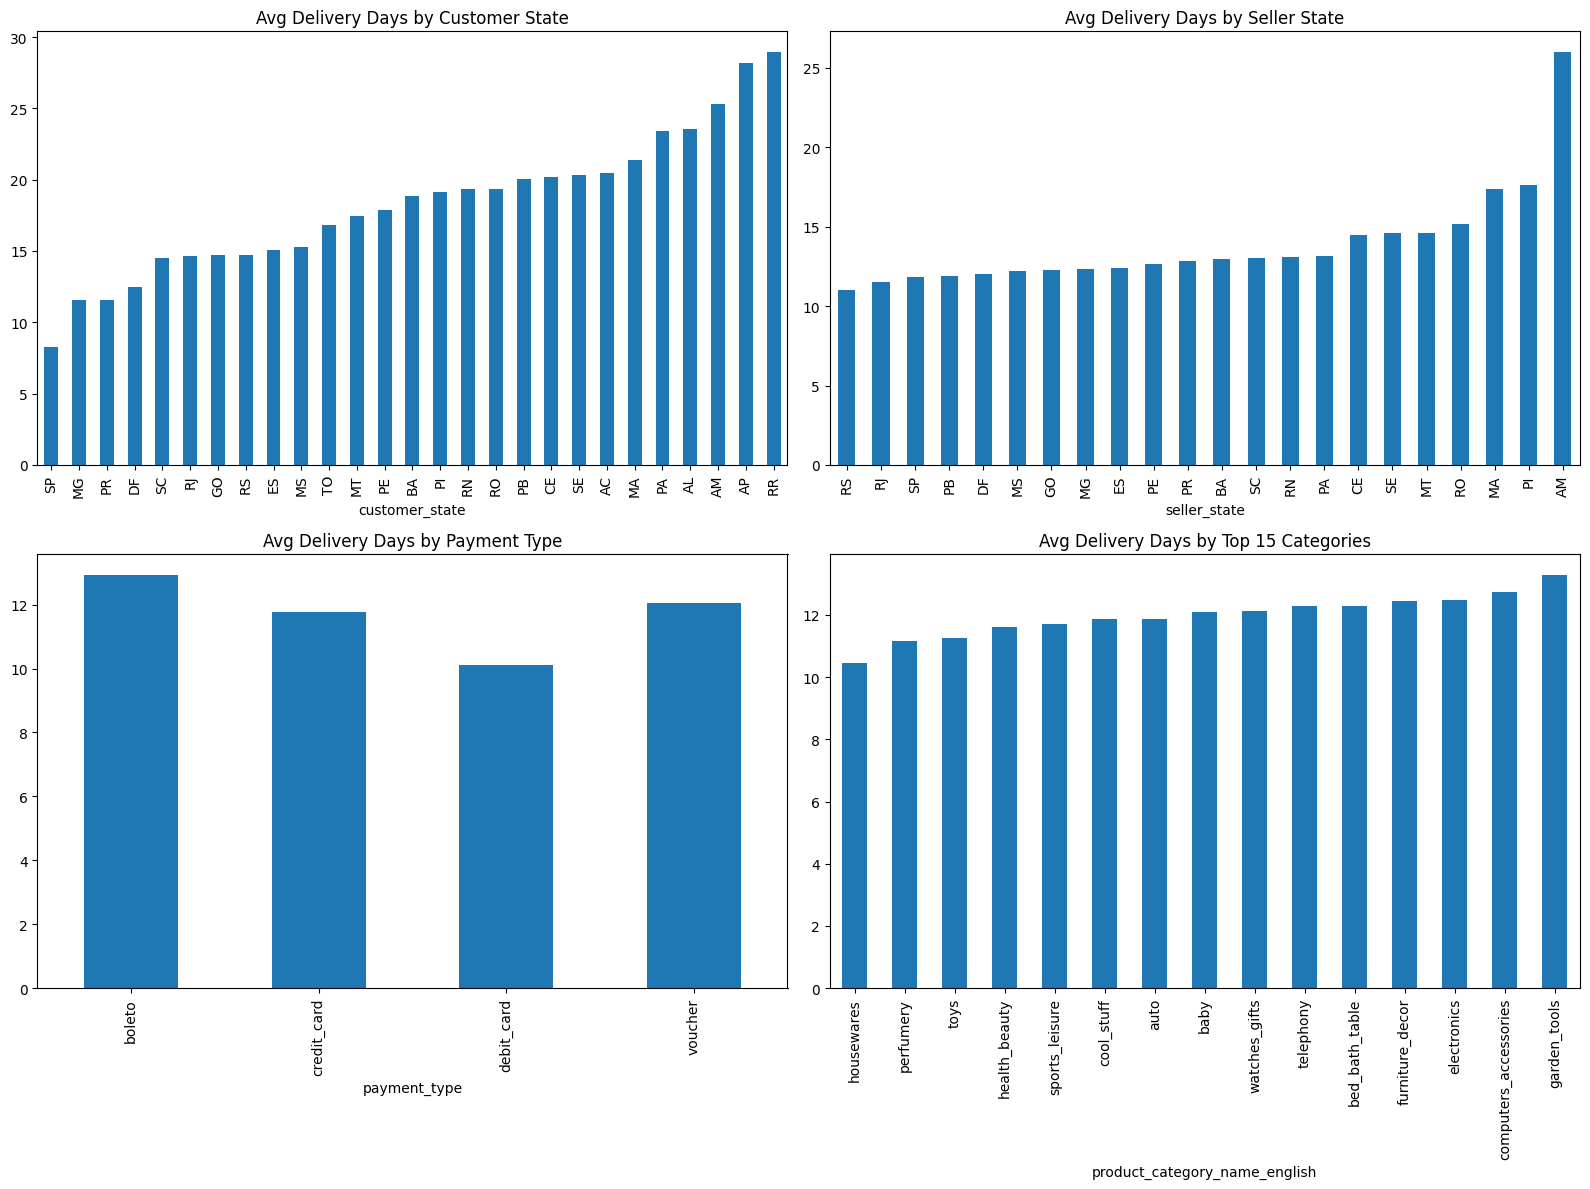

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Customer state vs delivery days
state_avg = data.groupby('customer_state')['delivery_days'].mean().sort_values()
state_avg.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Avg Delivery Days by Customer State')

# Seller state vs delivery days
seller_avg = data.groupby('seller_state')['delivery_days'].mean().sort_values()
seller_avg.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Avg Delivery Days by Seller State')

# Payment type vs delivery days
data.groupby('payment_type')['delivery_days'].mean().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Avg Delivery Days by Payment Type')

# Product category vs delivery days
top_cats = data['product_category_name_english'].value_counts().head(15).index
cat_data = data[data['product_category_name_english'].isin(top_cats)]
cat_data.groupby('product_category_name_english')['delivery_days'].mean().sort_values().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Avg Delivery Days by Top 15 Categories')

plt.tight_layout()
plt.show()

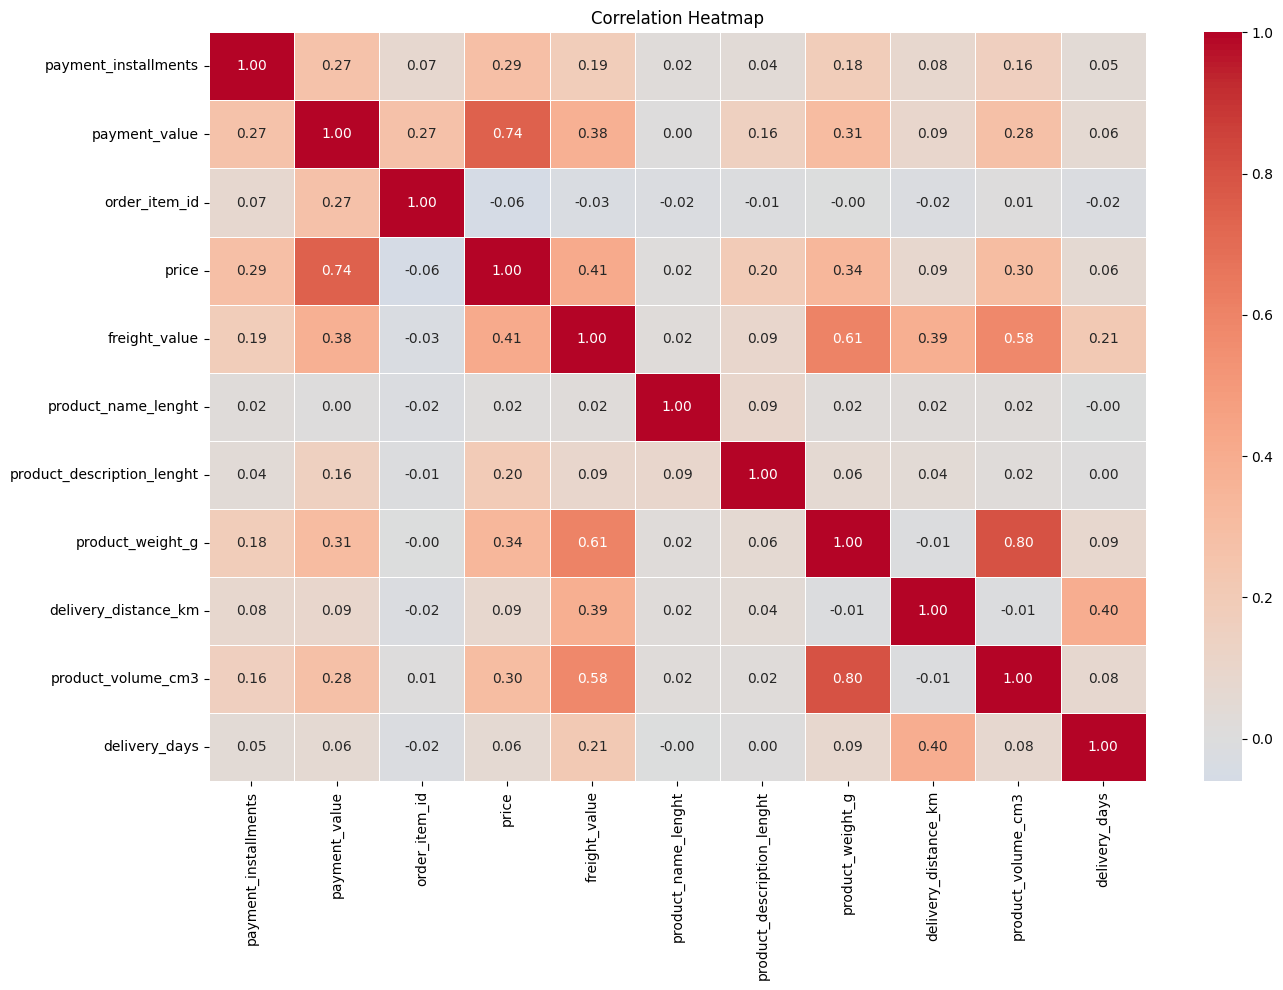

In [56]:
plt.figure(figsize=(14, 10))
corr_matrix = data.select_dtypes(include='number').corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [57]:
# Does same state = faster delivery?
data['same_state'] = (data['customer_state'] == data['seller_state']).astype(int)

from scipy import stats
same = data[data['same_state']==1]['delivery_days']
diff = data[data['same_state']==0]['delivery_days']

print(f"Same state avg:      {np.expm1(same.mean()):.1f} days")
print(f"Different state avg: {np.expm1(diff.mean()):.1f} days")

t_stat, p_value = stats.ttest_ind(same, diff)
print(f"P-value: {p_value:.5f}")

Same state avg:      1747.0 days
Different state avg: 2104542.7 days
P-value: 0.00000


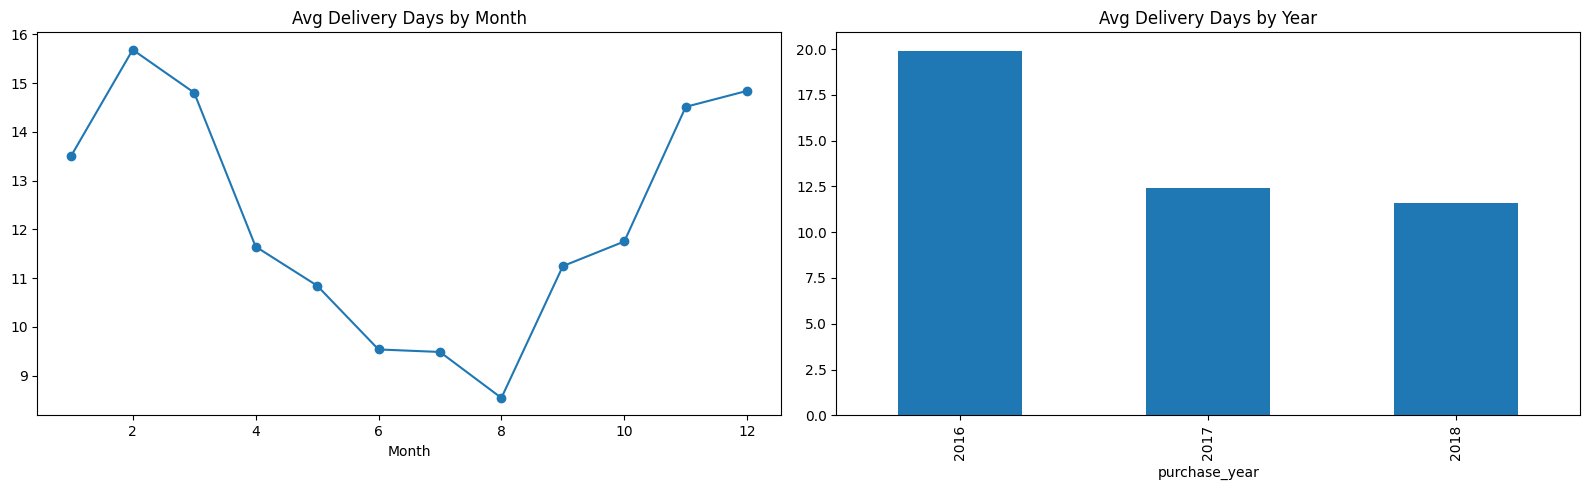

In [58]:
data['purchase_month'] = pd.to_datetime(data['order_purchase_timestamp']).dt.month
data['purchase_year'] = pd.to_datetime(data['order_purchase_timestamp']).dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly trend
data.groupby('purchase_month')['delivery_days'].mean().plot(
    kind='line', marker='o', ax=axes[0])
axes[0].set_title('Avg Delivery Days by Month')
axes[0].set_xlabel('Month')

# Yearly trend
data.groupby('purchase_year')['delivery_days'].mean().plot(
    kind='bar', ax=axes[1])
axes[1].set_title('Avg Delivery Days by Year')

plt.tight_layout()
plt.show()

In [60]:

missing = data.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No missing values!")
else:
    print(missing)
    print("\nMissing percentage:")
    print((missing / len(data) * 100).round(2))


✅ No missing values!
